# 😷 Face Mask Detection System
**Submitted for:** Final Graduation Project - AI Dev-Camp
**Prepared by:** Engineer Shehab Ameen

---
## 🎯 1. Problem Definition
* **The Problem:** The difficulty and high cost of continuous human monitoring to ensure compliance with wearing face masks in public and enclosed spaces to limit the spread of respiratory diseases.
* **Proposed Solution:** Building an Artificial Intelligence (Computer Vision) system capable of analyzing images and video streams in real-time to detect whether a person is wearing a mask or not.
* **Target Audience:** Security personnel, hospital administrations, and airports.


## 📁 2. Exploratory Data Analysis (EDA)
In this phase, we will load the dataset and inspect it to ensure its quality.
* **Data Source:** [https://drive.google.com/file/d/1a7Brk_hSxQPCAbPUF-qx0yPr-tlaljjK/view?usp=sharing]
* The objective of the following code is to count the number of images in each class (With Mask / Without Mask) and visualize the distribution to check for any **Data Imbalance**.


# All Required Libraries

In [1]:
# 1. System and OS operations
import os
import glob
import random
import shutil
import warnings
from pathlib import Path

# 2. Data Manipulation and Visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

# 3. Computer Vision and Machine Learning
import cv2
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# 4. Deep Learning (TensorFlow & Keras)
import tensorflow as tf
from tensorflow.keras import layers, models, Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.callbacks import EarlyStopping

# Ignore annoying warning messages
warnings.filterwarnings("ignore")

print("تمت تهيئة بيئة العمل واستدعاء المكتبات بنجاح!")


تمت تهيئة بيئة العمل واستدعاء المكتبات بنجاح!


# Exploratory Data Analysis (EDA)

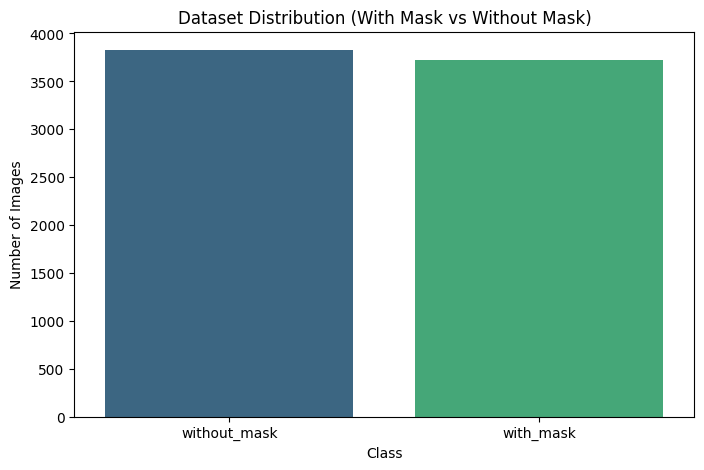


 Data Details: {'without_mask': 3828, 'with_mask': 3725}


In [3]:
dataset_path = 'dataset/data' 

if not os.path.exists(dataset_path):
    print(f"{dataset_path} is not exists")
else:
    classes = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]
    data_counts = {}

    for cls in classes:
        count = len(os.listdir(os.path.join(dataset_path, cls)))
        data_counts[cls] = count

    plt.figure(figsize=(8, 5))
    sns.barplot(x=list(data_counts.keys()), y=list(data_counts.values()), palette='viridis')
    plt.title('Dataset Distribution (With Mask vs Without Mask)')
    plt.xlabel('Class')
    plt.ylabel('Number of Images')
    plt.show()

    print("\n Data Details:", data_counts)


# Split dataset into Tran & Test folder: Run only 1 time

In [5]:
random.seed(1337) # For reproducibility
input_dir = Path("dataset/data")     
output_root = Path("dataset/split")  
train_ratio = 0.8 # 80% for training, 20% for testing

# Check if the split already exists to avoid redundant copying
if output_root.exists() and any(output_root.iterdir()):
    print("Dataset is already split. No need to split again.")
else:
    print("Splitting dataset and copying images... Please wait (this might take a few seconds)")
    
    # Create main directories
    (output_root / "train").mkdir(parents=True, exist_ok=True)
    (output_root / "test").mkdir(parents=True, exist_ok=True)

    # Discover class folders
    classes = [d.name for d in input_dir.iterdir() if d.is_dir()]

    for cls in classes:
        src_class = input_dir / cls
        files = [p for p in src_class.iterdir() if p.is_file()]
        random.shuffle(files) # Shuffle the images randomly
        
        split_idx = int(len(files) * train_ratio)
        train_files = files[:split_idx]
        test_files = files[split_idx:]
        
        # Create class subdirectories
        (output_root / "train" / cls).mkdir(parents=True, exist_ok=True)
        (output_root / "test" / cls).mkdir(parents=True, exist_ok=True)
        
        # Copy files
        for p in train_files:
            shutil.copy2(p, output_root / "train" / cls / p.name)
        for p in test_files:
            shutil.copy2(p, output_root / "test" / cls / p.name)

    print(f"Done! Train/Test split created successfully at: {output_root}")


Dataset is already split. No need to split again.


# Data Loading and Preprocessing

In [9]:
print("⏳ Loading datasets for training...")

train_dir = 'dataset/split/train'
test_dir = 'dataset/split/test'
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# 1. Load Training Dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True 
)

# 2. Load Testing Dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False 
)

# 3. Normalization
print("\n Applying Normalization (Rescaling)...")
normalization_layer = layers.Rescaling(1./255)
train_ds_new = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds_new = test_ds.map(lambda x, y: (normalization_layer(x), y))

# 4. Configure dataset for performance to avoid pickling errors
AUTOTUNE = tf.data.AUTOTUNE
train_ds_new = train_ds_new.cache().prefetch(buffer_size=AUTOTUNE)
test_ds_new = test_ds_new.cache().prefetch(buffer_size=AUTOTUNE)

print(" Data Loading and Preprocessing Completed Successfully!")


⏳ Loading datasets for training...
Found 6042 files belonging to 2 classes.
Found 1511 files belonging to 2 classes.

 Applying Normalization (Rescaling)...
 Data Loading and Preprocessing Completed Successfully!


# Convolution Architecture (Transfer Learning)

In [4]:
from tensorflow.keras.layers import Input, RandomFlip, RandomRotation, RandomZoom

print(" Building model with Data Augmentation layer...")

# 1. Create the Data Augmentation layer
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
], name="data_augmentation")

# 2. Build the Base Model (ResNet50)
base_model = ResNet50(input_shape=(128, 128, 3), include_top=False, weights='imagenet')
base_model.trainable = False # Start frozen

# 3. Build the final architecture
model = Sequential([
    Input(shape=(128, 128, 3)),
    data_augmentation,
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    BatchNormalization(),
    Dropout(0.5), # Increased dropout even more because augmentation is a strong regularizer
    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

# 4. Compile for Stage 1
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(" Model with Data Augmentation is ready!")
model.summary()


 Building model with Data Augmentation layer...
 Model with Data Augmentation is ready!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,146,946 (92.11 MB)

 Trainable params: 558,466 (2.13 MB)

 Non-trainable params: 23,588,480 (89.98 MB)

# Model Training

In [11]:
print("\n Stage 1 with Augmentation: Training the custom head...")
early_stop_1 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_1 = model.fit(
    train_ds_new, 
    validation_data=test_ds_new, 
    epochs=20, # More epochs for the head to learn from augmented data
    callbacks=[early_stop_1]
)

# --- Stage 2: Fine-Tuning ---
print("\n Stage 2 with Augmentation: Starting Fine-Tuning...")
base_model.trainable = True
for layer in base_model.layers[:-10]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # 0.00001
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_2 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_2 = model.fit(
    train_ds_new,
    validation_data=test_ds_new,
    epochs=40, # More epochs for fine-tuning
    initial_epoch=len(history_1.epoch),
    callbacks=[early_stop_2]
)



 Stage 1 with Augmentation: Training the custom head...
Epoch 1/20


189/189 ━━━━━━━━━━━━━━━━━━━━ 124s 619ms/step - accuracy: 0.5752 - loss: 0.9721 - val_accuracy: 0.5374 - val_loss: 0.6726
Epoch 2/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 112s 592ms/step - accuracy: 0.6383 - loss: 0.7018 - val_accuracy: 0.4964 - val_loss: 0.7654
Epoch 3/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 108s 574ms/step - accuracy: 0.6835 - loss: 0.6143 - val_accuracy: 0.6956 - val_loss: 0.5917
Epoch 4/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 107s 569ms/step - accuracy: 0.7239 - loss: 0.5661 - val_accuracy: 0.7128 - val_loss: 0.5496
Epoch 5/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 109s 579ms/step - accuracy: 0.7187 - loss: 0.5617 - val_accuracy: 0.5235 - val_loss: 0.8642
Epoch 6/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 107s 565ms/step - accuracy: 0.7215 - loss: 0.5513 - val_accuracy: 0.5255 - val_loss: 0.9588
Epoch 7/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 107s 566ms/step - accuracy: 0.7305 - loss: 0.5376 - val_accuracy: 0.6042 - val_loss: 0.9857
Epoch 8/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 170s 899ms/step - accuracy: 0.7201 - loss: 0.53

In [ ]:
model.save("face_mask_model_v5_augmented.keras")
print("\n Augmentation Training Completed! Final model saved as 'face_mask_model_v5_augmented.keras'")


 Augmentation Training Completed! Final model saved as 'face_mask_model_v5_augmented.keras'


# Model Evaluation & Visualization

 Generating model evaluation plots...


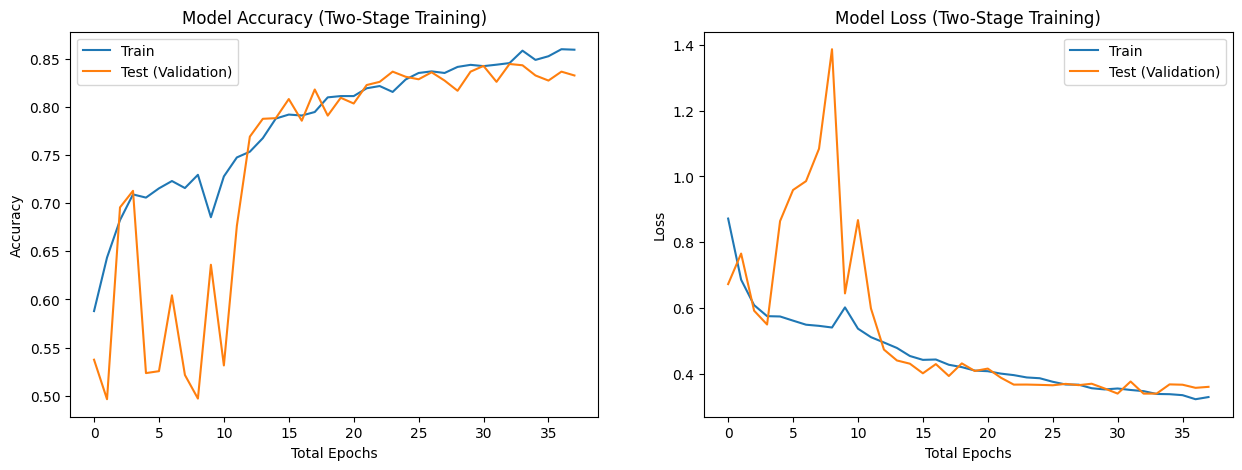


 Evaluating model on the Test Dataset and generating Confusion Matrix...
48/48 ━━━━━━━━━━━━━━━━━━━━ 24s 469ms/step


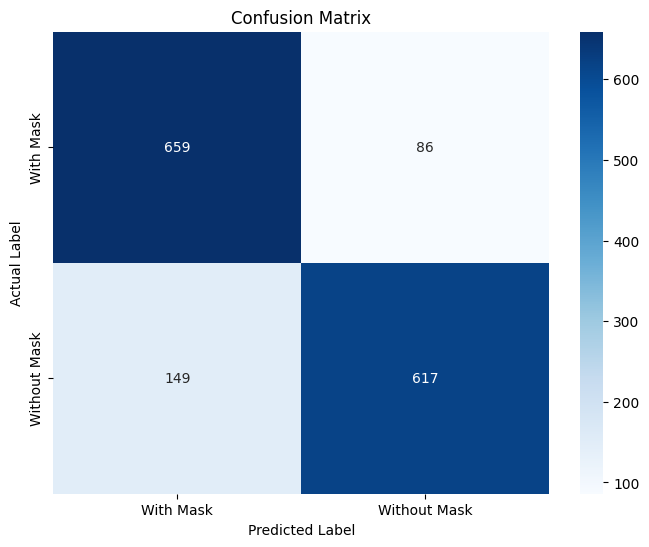


 Classification Report:
              precision    recall  f1-score   support

   With Mask       0.82      0.88      0.85       745
Without Mask       0.88      0.81      0.84       766

    accuracy                           0.84      1511
   macro avg       0.85      0.85      0.84      1511
weighted avg       0.85      0.84      0.84      1511



In [15]:
print(" Generating model evaluation plots...")

# 1. Plot Accuracy & Loss Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot training & validation accuracy values
# We combine history_1 and history_2 to show the full Two-Stage Training journey
full_accuracy = history_1.history['accuracy'] + history_2.history['accuracy']
full_val_accuracy = history_1.history['val_accuracy'] + history_2.history['val_accuracy']

ax1.plot(full_accuracy, label='Train')
ax1.plot(full_val_accuracy, label='Test (Validation)')
ax1.set_title('Model Accuracy (Two-Stage Training)')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Total Epochs')
ax1.legend(loc='upper left')

# Plot training & validation loss values
full_loss = history_1.history['loss'] + history_2.history['loss']
full_val_loss = history_1.history['val_loss'] + history_2.history['val_loss']

ax2.plot(full_loss, label='Train')
ax2.plot(full_val_loss, label='Test (Validation)')
ax2.set_title('Model Loss (Two-Stage Training)')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Total Epochs')
ax2.legend(loc='upper right')

plt.show()

# 2. Generate Predictions and Confusion Matrix
print("\n Evaluating model on the Test Dataset and generating Confusion Matrix...")

# Get true labels from the test dataset
y_true = np.concatenate([y for x, y in test_ds_new], axis=0)

# Get predicted labels from our model
y_pred_prob = model.predict(test_ds_new)
y_pred = np.argmax(y_pred_prob, axis=1)

# Generate Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
class_names = ['With Mask', 'Without Mask']

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 3. Display Classification Report
print("\n Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


# Interactive Manual Testing

🧪 Interactive Testing: Please upload an image!


FileUpload(value=(), accept='image/*', description='Upload')

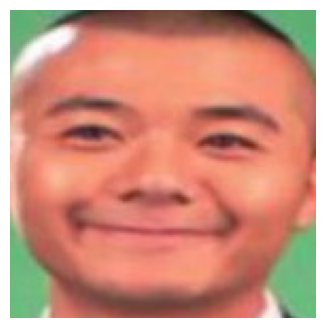

 Raw Probabilities: [0.01389151 0.9861085 ]
----------------------------------------
 Prediction: No Mask (Confidence: 98.61%)
----------------------------------------


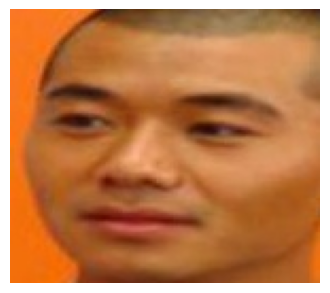

 Raw Probabilities: [0.00605844 0.99394155]
----------------------------------------
 Prediction: No Mask (Confidence: 99.39%)
----------------------------------------


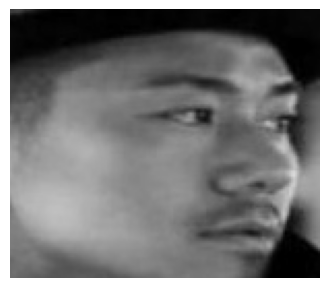

 Raw Probabilities: [0.3414593 0.6585407]
----------------------------------------
 Prediction: No Mask (Confidence: 65.85%)
----------------------------------------


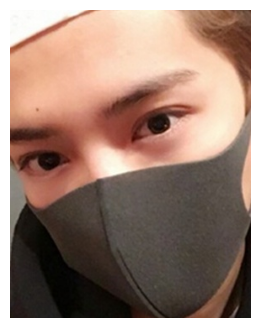

 Raw Probabilities: [0.98265934 0.01734062]
----------------------------------------
 Prediction: Mask (Confidence: 98.27%)
----------------------------------------


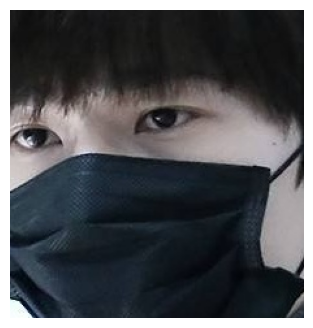

 Raw Probabilities: [0.99884605 0.00115398]
----------------------------------------
 Prediction: Mask (Confidence: 99.88%)
----------------------------------------


In [14]:
import ipywidgets as widgets
from IPython.display import display
from PIL import Image
import io
import numpy as np
import matplotlib.pyplot as plt

try:
    class_names = train_ds.class_names
    print(f" Model Classes Order: {class_names}")
except:
    class_names = ['Mask', 'No Mask']

print("🧪 Interactive Testing: Please upload an image!")

upload_button = widgets.FileUpload(accept='image/*', multiple=False)
display(upload_button)

def predict_uploaded_image(change):
    if upload_button.value:
        try:
            if isinstance(upload_button.value, tuple):
                content = upload_button.value[0]['content']
            else:
                file_name = list(upload_button.value.keys())[0]
                content = upload_button.value[file_name]['content']

            image = Image.open(io.BytesIO(content)).convert('RGB')
            
            plt.figure(figsize=(4, 4))
            plt.imshow(image)
            plt.axis('off')
            plt.show()

            img_resized = image.resize((128, 128))
            img_array = np.array(img_resized, dtype='float32') / 255.0
            img_input = np.expand_dims(img_array, axis=0)

            predictions = model.predict(img_input, verbose=0)
            
            print(f" Raw Probabilities: {predictions[0]}")
            
            # index 0: with_mask, index 1: without_mask
            mask_prob = predictions[0][0]
            no_mask_prob = predictions[0][1]

            print("-" * 40)
            if mask_prob > no_mask_prob:
                print(f" Prediction: {class_names[0]} (Confidence: {mask_prob*100:.2f}%)")
            else:
                print(f" Prediction: {class_names[1]} (Confidence: {no_mask_prob*100:.2f}%)")
            print("-" * 40)

        except Exception as e:
            print(f" Error: {e}")

upload_button.observe(predict_uploaded_image, names='value')


# FINAL MODEL DEPLOYMENT & TESTING

 Finalizing Deployment Environment...
 SUCCESS: Expert weights loaded from 'face_mask_model_v5_augmented.keras'

 TEST YOUR PROJECT: Upload an image to see the AI in action!


FileUpload(value=(), accept='image/*', description='Upload')

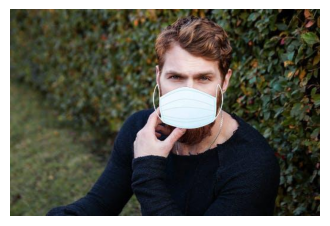

 RESULT: With Mask (Confidence: 86.16%)


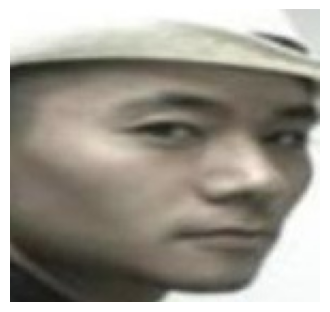

 RESULT: Without Mask (Confidence: 94.08%)


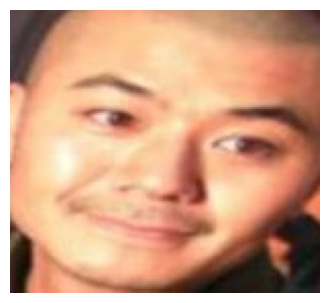

 RESULT: Without Mask (Confidence: 96.15%)


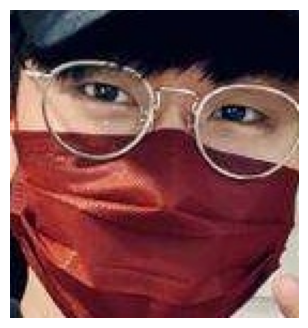

 RESULT: With Mask (Confidence: 67.70%)


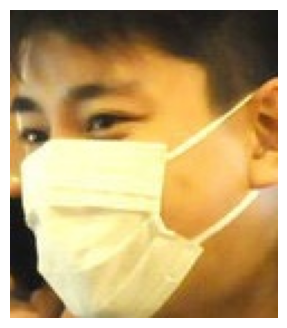

 RESULT: With Mask (Confidence: 92.66%)


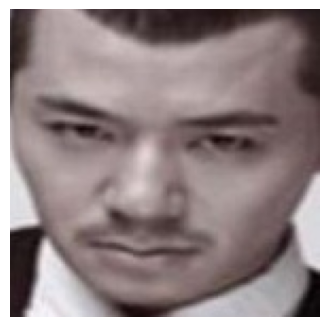

 RESULT: Without Mask (Confidence: 97.80%)


In [13]:
import ipywidgets as widgets
from IPython.display import display
from PIL import Image
import io
import numpy as np
import matplotlib.pyplot as plt

print(" Finalizing Deployment Environment...")

# 1. Re-build the Architecture
base_model_final = ResNet50(input_shape=(128, 128, 3), include_top=False, weights='imagenet')
base_model_final.trainable = False 

final_deployed_model = Sequential([
    Input(shape=(128, 128, 3)),
    base_model_final,
    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    BatchNormalization(),
    Dropout(0.5),
    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

# 2. Load the Weights with a Success Flag
weights_file = "face_mask_model_v5_augmented.keras"
is_ready = False 

try:
    final_deployed_model.load_weights(weights_file)
    print(f" SUCCESS: Expert weights loaded from '{weights_file}'")
    is_ready = True 
except Exception as e:
    print(f" FATAL ERROR: Could not load weights. {e}")
    print(" Deployment stopped. Please make sure the weights file exists in the folder.")

# 3. Interactive UI (Only if ready!)
if is_ready:
    print("\n TEST YOUR PROJECT: Upload an image to see the AI in action!")
    uploader = widgets.FileUpload(accept='image/*', multiple=False)
    display(uploader)

    def run_inference(change):
        if uploader.value:
            try:
                if isinstance(uploader.value, tuple):
                    content = uploader.value[0]['content']
                else:
                    file_name = list(uploader.value.keys())[0]
                    content = uploader.value[file_name]['content']

                img = Image.open(io.BytesIO(content)).convert('RGB')
                
                plt.figure(figsize=(4, 4))
                plt.imshow(img)
                plt.axis('off')
                plt.show()

                img_processed = np.array(img.resize((128, 128)), dtype='float32') / 255.0
                prediction = final_deployed_model.predict(np.expand_dims(img_processed, axis=0), verbose=0)[0]
                
                labels = ["With Mask", "Without Mask"] 
                result_idx = np.argmax(prediction)
                confidence = prediction[result_idx] * 100

                print("="*40)
                if result_idx == 0:
                    print(f" RESULT: {labels[0]} (Confidence: {confidence:.2f}%)")
                else:
                    print(f" RESULT: {labels[1]} (Confidence: {confidence:.2f}%)")
                print("="*40)
            except Exception as e:
                print(f" Inference Error: {e}")

    uploader.observe(run_inference, names='value')
else:
    print("\n Testing interface is disabled because the model weights are missing.")
